In [1]:
import numpy as np  
import pandas as pd  
import statsmodels.api as sm  
import matplotlib.pyplot as plt  
import seaborn as sns 

In [2]:
np.random.seed(42)  
x = np.random.rand(100) * 10  # Advertising Spend (in $1000s)
y = 2.5 * x + np.random.normal(size=100) * 3  # Sales with noise  

data = pd.DataFrame({'x': x, 'y': y}) 

In [3]:
X = sm.add_constant(data['x'])  # Adding a constant for the intercept
model = sm.OLS(data['y'], X).fit()
data['y_pred'] = model.predict(X)
residuals = model.resid

### Linearity

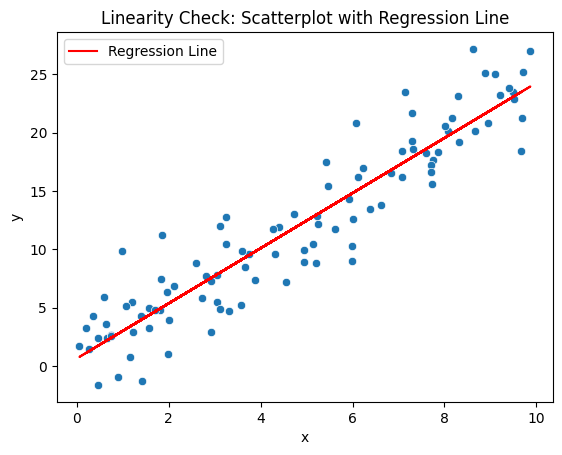

In [4]:
sns.scatterplot(x='x', y='y', data=data)  
plt.plot(data['x'], data['y_pred'], color='red', label='Regression Line')  
plt.title('Linearity Check: Scatterplot with Regression Line')  
plt.legend()
plt.show()

### Independence of Errors

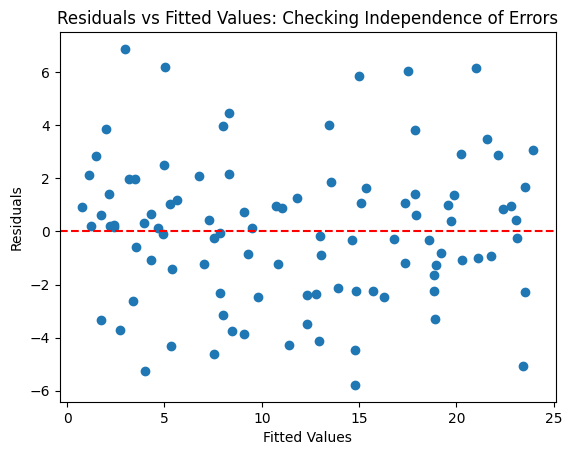

In [5]:
plt.scatter(data['y_pred'], residuals)  
plt.axhline(0, color='red', linestyle='--')  
plt.title('Residuals vs Fitted Values: Checking Independence of Errors')  
plt.xlabel('Fitted Values')  
plt.ylabel('Residuals')  
plt.show() 

### Normality of Errors

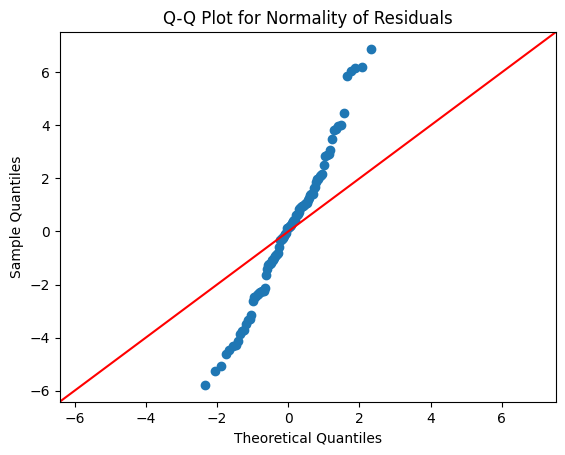

In [6]:
sm.qqplot(residuals, line='45')  
plt.title('Q-Q Plot for Normality of Residuals')  
plt.show()

### Equal Variances (Homoscedasticity)

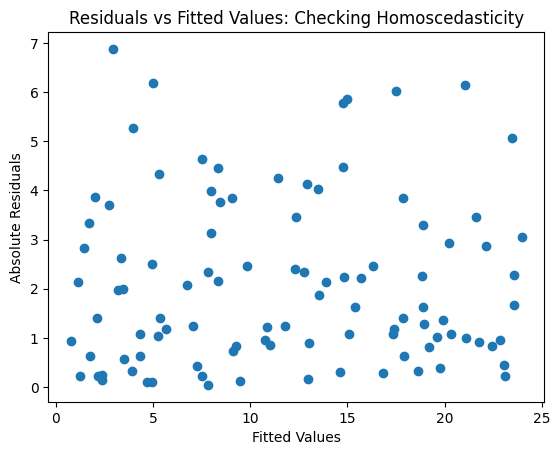

In [8]:
plt.scatter(data['y_pred'], np.abs(residuals))  
plt.title('Residuals vs Fitted Values: Checking Homoscedasticity')  
plt.xlabel('Fitted Values')  
plt.ylabel('Absolute Residuals')  
plt.show()